# EPC05 Transformar e Conquistar

Implemente três versões de algoritmos para o cálculo da moda de uma lista de números inteiros:

1. Força Bruta
2. Space-Time Tradeoff
3. Transformar e Consquistar

Todos os algoritmos devem ser implementados em python sem utilizar nenhuma biblioteca externa. Eles devem receber como parâmetro uma lista com números aleatórios. Para que a comparação seja justa, passe a mesma lista para todos os algoritmos!!!
 
Você deve implementar também um código que gere um gráfico comparando o desempenho dos algoritmos.

Você deve enviar o código dos algoritmos e do gráfico em um arquivo único no formato .ipypnb.

In [69]:
from typing import List

In [70]:
def brute_force_mode(L:List) -> int | float:
    
    mode = L[0]
    freq_max = 0
    for i in range(len(L)):
        current_count = 0

        for j in range(i+1, len(L)):
            if L[i] == L[j]:
                current_count+=1
        
        if current_count > freq_max:
            freq_max = current_count
            mode = L[i]
    return mode

In [71]:
lista = [2, 10, 1, 0, 3, 3]

print(f"Moda: {brute_force_mode(lista)}")

Moda: 3


In [72]:
#Space-Time Tradeoff
def mode_space_time_tradeoff(L:List) -> int | float:
    hash_table = dict()
    mode = L[0]
    freq_max = 0

    for i in range(len(L)):
        current_element = L[i]

        if L[i] in hash_table:
            hash_table[current_element] = hash_table[current_element] + 1
        else:
            hash_table[current_element] = 1
        
        if hash_table[current_element] > freq_max:
            freq_max = hash_table[current_element]
            mode = current_element
        
    return mode

In [73]:
lista = [2, 10, 1, 0, 3, 3]

print(f"Moda: {mode_space_time_tradeoff(lista)}")

Moda: 3


In [74]:
#Transformar e Consquistar

def presort_mode(L:List) -> int | float:
    L.sort()
    i = 0
    freq_mode = 0

    while i < len(L):
        run_leng = 0
        run_value = L[i]

        while i + run_leng < len(L) and L[i + run_leng] == run_value:
            run_leng += 1
        if run_leng > freq_mode:
            freq_mode = run_leng
            mode_value = run_value
        i += run_leng
    return mode_value

In [75]:
lista = [2, 10, 1, 0, 3, 3]

print(f"Moda: {presort_mode(lista)}")

Moda: 3


In [76]:
import time
import random as py_random

DOMAIN = 1_000_000_000
py_random.seed(31)

import sys

sys.setrecursionlimit(1000000)
algorithms = [
    brute_force_mode,
    mode_space_time_tradeoff,
    presort_mode
]

num_rounds = 3

sizes = [1000, 5000, 10000, 20000, 50000]

mapSizeToTime = {}

for algorithm in algorithms:
    for size in sizes:
        for scenario in ["random", "sorted", "reverse"]:
            key = f"{algorithm.__name__}##{size}##{scenario}"
            mapSizeToTime[key] = 0


def executionTime(L, func):
    start = time.perf_counter()
    func(L)
    end = time.perf_counter()
    return end - start


# Coleta dos tempos
for r in range(num_rounds):

    print(f"Round {r+1}")

    for size in sizes:

        # mesma lista para todos os algoritmos
        L_random = py_random.sample(range(DOMAIN), size)

        L_sorted = sorted(L_random)

        L_reverse = sorted(L_random, reverse=True)

        for algorithm in algorithms:

            mapSizeToTime[f"{algorithm.__name__}##{size}##random"] += \
                executionTime(L_random.copy(), algorithm)

            mapSizeToTime[f"{algorithm.__name__}##{size}##sorted"] += \
                executionTime(L_sorted.copy(), algorithm)

            mapSizeToTime[f"{algorithm.__name__}##{size}##reverse"] += \
                executionTime(L_reverse.copy(), algorithm)

for key in mapSizeToTime:
    mapSizeToTime[key] /= num_rounds

print("Coleta finalizada.")

Round 1
Round 2
Round 3
Coleta finalizada.


In [77]:
import pandas as pd

df = pd.DataFrame.from_dict(
    mapSizeToTime,
    orient="index",
    columns=["Time"]
)

df["Algorithm"] = [i.split("##")[0] for i in df.index]
df["Size"] = [int(i.split("##")[1]) for i in df.index]
df["Scenario"] = [i.split("##")[2] for i in df.index]

df

,Time,Algorithm,Size,Scenario
brute_force_mode##1000##random,0.012170,brute_force_mode,1000,random
brute_force_mode##1000##sorted,0.011153,brute_force_mode,1000,sorted
brute_force_mode##1000##reverse,0.012139,brute_force_mode,1000,reverse
brute_force_mode##5000##random,0.276104,brute_force_mode,5000,random
brute_force_mode##5000##sorted,0.269348,brute_force_mode,5000,sorted
brute_force_mode##5000##reverse,0.263804,brute_force_mode,5000,reverse
brute_force_mode##10000##random,1.097514,brute_force_mode,10000,random
brute_force_mode##10000##sorted,1.142423,brute_force_mode,10000,sorted
brute_force_mode##10000##reverse,1.151308,brute_force_mode,10000,reverse
brute_force_mode##20000##random,4.268742,brute_force_mode,20000,random


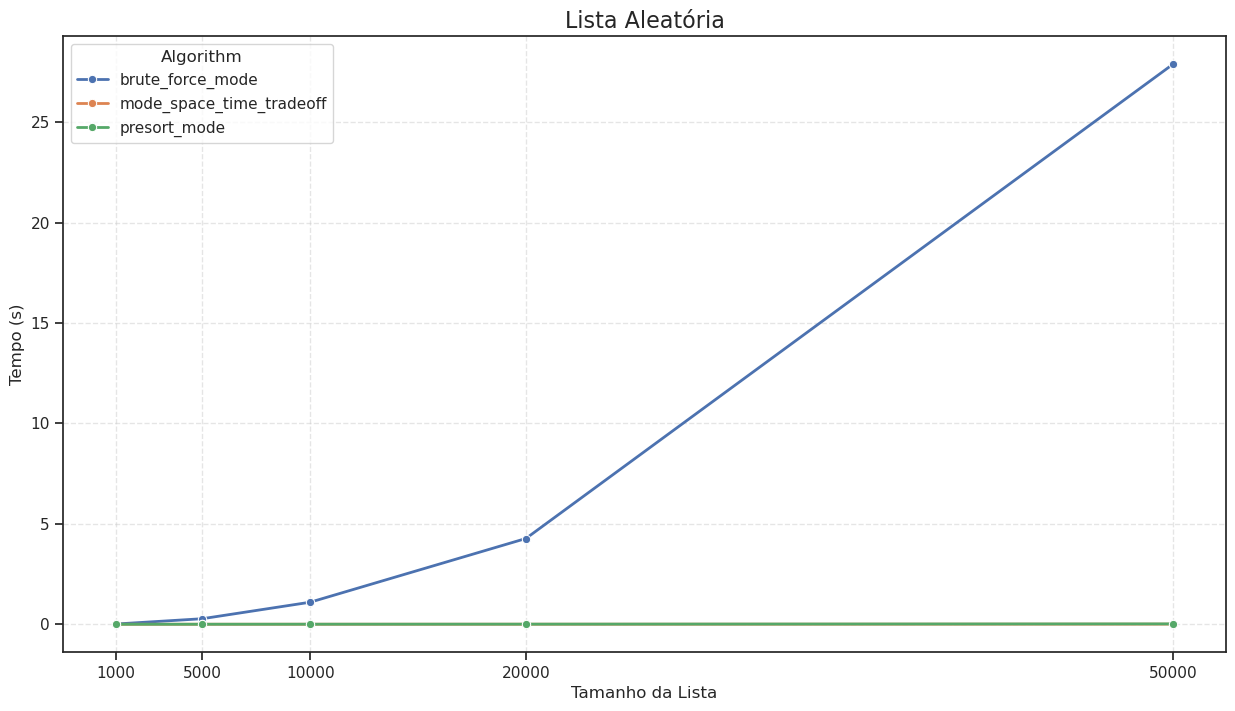

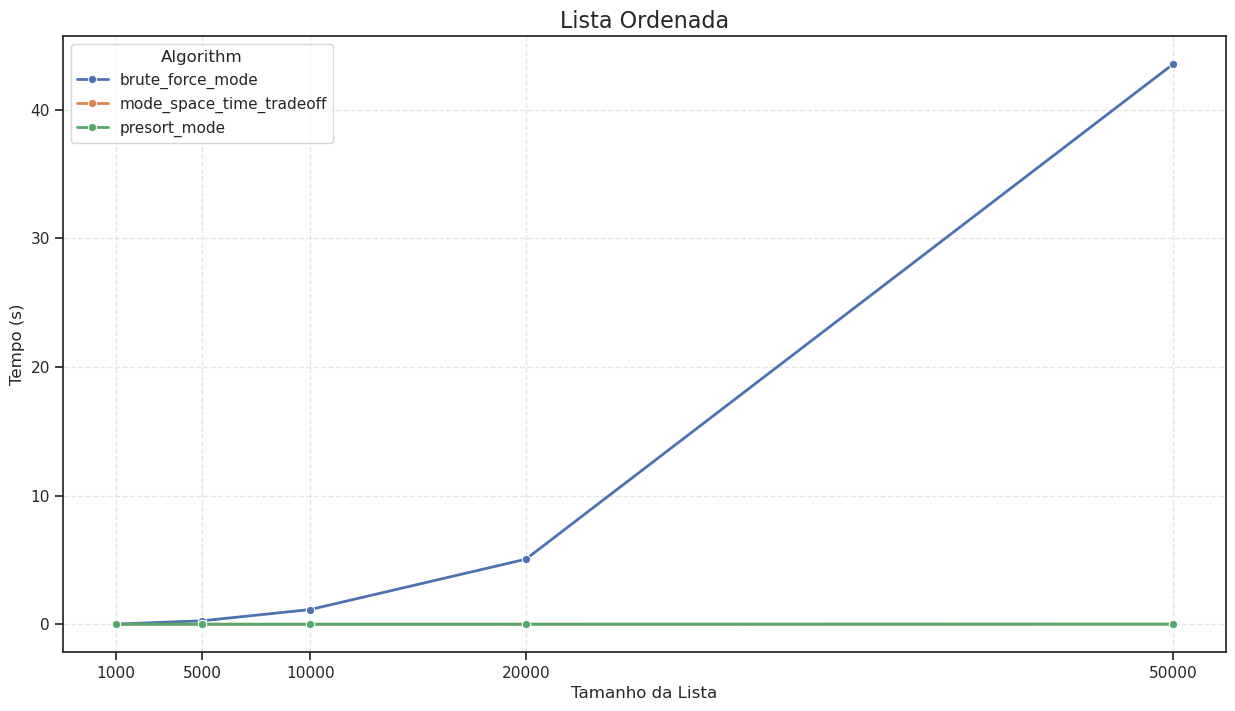

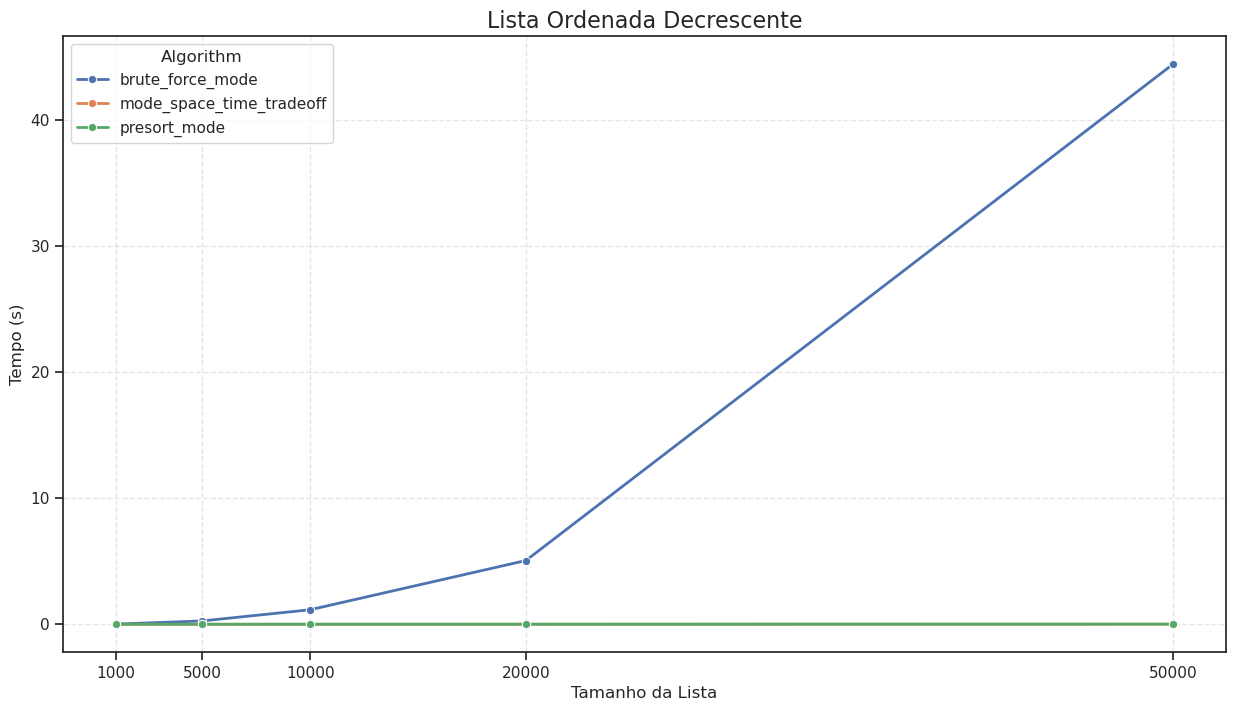

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=1, style="ticks", rc={"lines.linewidth": 2})

for scenario in ["random", "sorted", "reverse"]:

    plt.figure(figsize=(15,8))

    g = sns.lineplot(
        data=df[df["Scenario"] == scenario],
        x="Size",
        y="Time",
        hue="Algorithm",
        marker="o"
    )

    g.set(xticks=sizes)

    if scenario == "random":
        titulo = "Lista Aleatória"
    elif scenario == "sorted":
        titulo = "Lista Ordenada"
    else:
        titulo = "Lista Ordenada Decrescente"

    g.set_title(titulo, fontsize=16)
    g.set_xlabel("Tamanho da Lista")
    g.set_ylabel("Tempo (s)")

    plt.grid(True, ls="--", alpha=0.5)
    plt.show()